# L1 vs L2 SLSQP on the canonical synthetic cases — with reactive warm-start

Companion to `09_horizontal-vs-diagonal-bowtie.ipynb` and `10_preprocessing-warm-start.ipynb`. Earlier notebooks `02_optimization.ipynb` and `05_solver-engineering.ipynb` introduced a **reactive warm-start** for L2 SLSQP: when SLSQP terminates with `success=False` and `status=8` ("positive directional derivative for line-search" — i.e., stuck at a saddle on the constraint boundary), perturb the current iterate by Gaussian noise σ=0.01 and resume from there. This routinely unsticks the optimiser on the bowtie under L2.

The reactive warm-start is **objective-agnostic** — nothing in it assumes L2. This notebook tests whether it also rescues **L1 SLSQP**, which (per `10`) tends to stall on cold starts. We compare:

- **cold** — vanilla SLSQP from `phi_anchor`. No retry on stall. Reference baseline.
- **warm** — vanilla SLSQP, then on `status=8` failure: perturb by Gaussian σ=0.01, resume with a higher iter cap and `ftol=1e-10`. (Same recipe as `02_optimization.ipynb`.)

Both modes are run under both objectives (L2 and smoothed L1) on the canonical synthetic test cases:

| case | shape | source | first used in |
|---|---|---|---|
| `01a_10x10_crossing` | 10×10 | `test_cases.SYNTHETIC_CASES` | `01_vs-central-diff.ipynb` |
| `01b_10x10_opposite` | 10×10 | `test_cases.SYNTHETIC_CASES` | `01_vs-central-diff.ipynb` |
| `03c_20x20_opposite` | 20×20 | `test_cases.SYNTHETIC_CASES` | `01_vs-central-diff.ipynb`, `08_global-invertibility-gap.ipynb` |
| `03d_20x20_crossing` | 20×20 | `test_cases.SYNTHETIC_CASES` | `01_vs-central-diff.ipynb`, `04_constraint-comparison.ipynb` |

The anchor stays at `phi_anchor` for every run — only the iterate gets perturbed. We report `total_nit` and `total_time` summed across the initial run plus any warm-restart, plus the usual `final_L2` / `final_L1` / `final_min_tr` per `(case, objective, mode)`.

**Per case we visualise** the side-by-side deformation grids (original / L2-warm-converged / L1-warm-converged) and per-pixel residual heatmaps for the L2 and L1 best solutions, with a shared colour scale to make the sparsity-vs-spread contrast directly visible.

In [1]:
import os, sys, time, io, contextlib, warnings
sys.path.insert(0, os.path.abspath('../..'))
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint

from dvfopt import DEFAULT_PARAMS, jacobian_det2D
from dvfopt.jacobian import triangle_sign_areas2D
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d
from dvfopt.viz.triangle_debug import find_problematic_pixels
from dvfopt.core.objective import objective_euc
import test_cases

THRESHOLD = DEFAULT_PARAMS['threshold']
EPS_L1 = 1e-4
print(f'THRESHOLD = {THRESHOLD},  EPS_L1 = {EPS_L1}')

THRESHOLD = 0.01,  EPS_L1 = 0.0001


In [2]:
def _l2(a, b): return float(np.linalg.norm(a - b))
def _l1(a, b): return float(np.abs(a - b).sum())

def _triangle_flat(dy, dx):
    T1, T2 = _triangle_areas_2d(dy, dx)
    return np.concatenate([T1.flatten(), T2.flatten()])

def _pack(phi):
    return np.concatenate([phi[1].flatten(), phi[0].flatten()])

def _unpack(z, H, W):
    pixels = H * W
    return z[pixels:].reshape(H, W), z[:pixels].reshape(H, W)  # dy, dx


def _objective(objective, eps=EPS_L1):
    if objective == 'l2':
        def obj(z, z_anchor):
            return objective_euc(z, z_anchor)
    elif objective == 'l1':
        def obj(z, z_anchor):
            diff = z - z_anchor
            s = np.sqrt(diff * diff + eps * eps)
            return float(s.sum()), diff / s
    else:
        raise ValueError(objective)
    return obj


def run_slsqp(phi_anchor, objective, max_iter, threshold=THRESHOLD,
              warm_start=False, warm_max_iter=2000, warm_ftol=1e-10,
              warm_sigma=0.01, warm_seed=123, eps=EPS_L1):
    """SLSQP with a generalised reactive warm-restart.

    Initial run: SLSQP from `phi_anchor` for up to `max_iter` iterations.
    If `warm_start=True` AND the initial run did not succeed:
      - If `status == 8` (line-search rejection): perturb the iterate by
        Gaussian noise of scale `warm_sigma` and resume. (The recipe from
        02_optimization.ipynb / 05_solver-engineering.ipynb.)
      - Otherwise (typically `status == 9`, iteration limit): simply resume
        from the current iterate with a bigger budget and tighter ftol -
        no perturbation, since the iterate is making real progress.
    Single retry only; the resumed run runs for up to `warm_max_iter` more.
    `total_nit` and `total_time` accumulate across initial + resumed runs.
    """
    _, H, W = phi_anchor.shape
    z_anchor = _pack(phi_anchor)
    obj = _objective(objective, eps=eps)

    def constr(z):
        dy, dx = _unpack(z, H, W)
        return _triangle_flat(dy, dx)

    nl = NonlinearConstraint(constr, lb=threshold, ub=np.inf)

    t0 = time.time()
    res = minimize(lambda z: obj(z, z_anchor),
                   z_anchor.copy(), jac=True, method='SLSQP',
                   constraints=[nl],
                   options={'maxiter': max_iter, 'ftol': 1e-9, 'disp': False})
    total_nit = res.nit
    warm_fired = False
    warm_reason = ''

    if warm_start and not res.success:
        warm_fired = True
        if res.status == 8:
            # Line-search stall - perturb to break degeneracy.
            rng = np.random.default_rng(warm_seed)
            z_warm = res.x + rng.normal(scale=warm_sigma, size=res.x.shape)
            warm_reason = f'status={res.status} (line-search stall); perturbed sigma={warm_sigma}'
        else:
            # Iter limit or other - just continue from current iterate.
            z_warm = res.x.copy()
            warm_reason = f'status={res.status} (no perturbation; resume with extra budget)'
        res = minimize(lambda z: obj(z, z_anchor),
                       z_warm, jac=True, method='SLSQP',
                       constraints=[nl],
                       options={'maxiter': warm_max_iter, 'ftol': warm_ftol, 'disp': False})
        total_nit += res.nit

    elapsed = time.time() - t0
    dy_out, dx_out = _unpack(res.x, H, W)
    phi_final = np.stack([dy_out, dx_out])
    tri = triangle_sign_areas2D(phi_final)
    return {
        'objective': objective,
        'phi': phi_final,
        'tri': tri,
        'min_tr': float(tri.min()),
        'n_neg_tr': int((tri <= 0).sum()),
        'final_l2': _l2(phi_final, phi_anchor),
        'final_l1': _l1(phi_final, phi_anchor),
        'nit': total_nit,
        't': elapsed,
        'success': bool(res.success),
        'status': int(res.status),
        'warm_fired': warm_fired,
        'warm_reason': warm_reason,
    }


def plot_warped_grid(ax, phi, title, highlight_folds=True, fontsize=8):
    dy, dx = phi[0], phi[1]
    H, W = dy.shape
    yy, xx = np.mgrid[:H, :W]
    gx, gy = xx + dx, yy + dy
    for i in range(H):
        ax.plot(xx[i], yy[i], color='#f0f0f0', lw=0.4)
    for j in range(W):
        ax.plot(xx[:, j], yy[:, j], color='#f0f0f0', lw=0.4)
    for i in range(H):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.8)
    for j in range(W):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.8)
    if highlight_folds:
        tri = triangle_sign_areas2D(phi)
        for (cy, cx) in np.argwhere(tri.min(axis=0) <= 0):
            px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(px, py, color='#1565c0', lw=1.4)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(title, fontsize=fontsize)
    ax.set_xticks([]); ax.set_yticks([])


def per_pixel_residual_l2(phi_final, phi_anchor):
    return np.linalg.norm(phi_final - phi_anchor, axis=0)

In [3]:
def _silent_make(case_key):
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        df, _, _ = test_cases.make_deformation(case_key)
    return df[1:, 0]  # (3, 1, H, W) -> (2, H, W) channels [dy, dx]

# Per-case cold-start iteration cap (`max_iter`) and warm-restart extra budget
# (`warm_max_iter`). The cold cap is chosen so L2 converges comfortably but L1
# does NOT — this triggers the warm-restart on L1 and lets us see whether
# resuming with extra budget actually rescues it. (Setting both caps high
# enough that L1 also converges from cold makes the warm-restart a no-op,
# which is what we observed in the previous run of this notebook.)
CASES = [
    # (case_key, cold_max_iter, warm_max_iter)
    ('01a_10x10_crossing',   50,  800),
    ('01b_10x10_opposite',   50,  800),
    ('03c_20x20_opposite',   80, 1000),
    ('03d_20x20_crossing',   80, 1000),
]
CASES = [(k, _silent_make(k), it_cold, it_warm) for (k, it_cold, it_warm) in CASES]

for name, phi, it_cold, it_warm in CASES:
    tri = triangle_sign_areas2D(phi)
    print(f'{name:<22s}  shape={phi.shape}  n_neg_tri={int((tri<=0).sum()):>4d}  '
          f'min_tr={float(tri.min()):+.3f}  '
          f'cold_max_iter={it_cold}  warm_max_iter={it_warm}')

01a_10x10_crossing      shape=(2, 10, 10)  n_neg_tri=  24  min_tr=-0.744  cold_max_iter=50  warm_max_iter=800
01b_10x10_opposite      shape=(2, 10, 10)  n_neg_tri=  10  min_tr=-0.587  cold_max_iter=50  warm_max_iter=800
03c_20x20_opposite      shape=(2, 20, 20)  n_neg_tri=  58  min_tr=-0.809  cold_max_iter=80  warm_max_iter=1000
03d_20x20_crossing      shape=(2, 20, 20)  n_neg_tri=  72  min_tr=-0.740  cold_max_iter=80  warm_max_iter=1000


In [4]:
results = {}

for name, phi, it_cold, it_warm in CASES:
    print(f'>>> {name}  (cold cap={it_cold}, warm extra={it_warm})', flush=True)
    t0 = time.time()
    case_runs = {}
    for obj_label in ('l2', 'l1'):
        for mode in ('cold', 'warm'):
            warm = (mode == 'warm')
            r = run_slsqp(phi, obj_label, max_iter=it_cold,
                          warm_start=warm, warm_max_iter=it_warm)
            case_runs[(obj_label, mode)] = r
            tag = f'{obj_label.upper():<2s} {mode:<4s}'
            warm_str = f'(warm fired: {r["warm_reason"]})' if r['warm_fired'] else ''
            print(f'    {tag}  ok={r["success"]!s:<5s} nit={r["nit"]:5d}  t={1000*r["t"]:8.0f}ms  '
                  f'final_L2={r["final_l2"]:7.3f}  final_L1={r["final_l1"]:7.3f}  '
                  f'min_tr={r["min_tr"]:+.3f}  {warm_str}', flush=True)
    results[name] = {'phi': phi, **case_runs,
                     'cold_max_iter': it_cold, 'warm_max_iter': it_warm}
    print(f'<<< done in {time.time()-t0:.1f}s', flush=True)

>>> 01a_10x10_crossing  (cold cap=50, warm extra=800)


    L2 cold  ok=True  nit=   34  t=     361ms  final_L2=  3.043  final_L1=  6.946  min_tr=+0.010  


    L2 warm  ok=True  nit=   34  t=     367ms  final_L2=  3.043  final_L1=  6.946  min_tr=+0.010  


    L1 cold  ok=False nit=   50  t=     699ms  final_L2=  3.927  final_L1= 16.873  min_tr=+0.004  


    L1 warm  ok=True  nit=  381  t=    4882ms  final_L2=  3.045  final_L1=  6.641  min_tr=+0.010  (warm fired: status=9 (no perturbation; resume with extra budget))


...

    L2 cold  ok=True  nit=   43  t=   15610ms  final_L2=  7.376  final_L1= 80.431  min_tr=+0.010  


    L2 warm  ok=True  nit=   43  t=   16270ms  final_L2=  7.376  final_L1= 80.431  min_tr=+0.010  


    L1 cold  ok=False nit=   80  t=   41678ms  final_L2= 11.576  final_L1=113.888  min_tr=-0.004  


    L1 warm  ok=False nit= 1080  t=  370916ms  final_L2=  7.990  final_L1= 46.275  min_tr=+0.010  (warm fired: status=9 (no perturbation; resume with extra budget))


<<< done in 444.5s


In [5]:
def _best_run(case_runs, obj):
    """Pick the run with lower final norm among feasible; fall back to highest min_tr."""
    candidates = [case_runs[(obj, m)] for m in ('cold', 'warm')]
    norm_key = 'final_l2' if obj == 'l2' else 'final_l1'
    feasible = [c for c in candidates if c['min_tr'] >= THRESHOLD - 1e-9]
    if feasible:
        return min(feasible, key=lambda r: r[norm_key])
    return max(candidates, key=lambda r: r['min_tr'])


print(f"{'case':<22s}  {'obj':<3s}  {'mode':<5s}  {'ok':>5s}  {'nit':>5s}  {'t(ms)':>8s}  "
      f"{'final L2':>9s}  {'final L1':>9s}  {'min_TR':>8s}  warm")
print('-' * 105)
for name, *_rest in CASES:
    rr = results[name]
    for obj in ('l2', 'l1'):
        for mode in ('cold', 'warm'):
            r = rr[(obj, mode)]
            print(f'{name:<22s}  {obj.upper():<3s}  {mode:<5s}  '
                  f'{str(r["success"]):>5s}  {r["nit"]:>5d}  {1000*r["t"]:>8.0f}  '
                  f'{r["final_l2"]:>9.3f}  {r["final_l1"]:>9.3f}  {r["min_tr"]:>+8.3f}  '
                  f'{r.get("warm_fired", False)!s:<5s}')

print()
print('Per-case best (warm vs cold) per objective:')
print(f"{'case':<22s}  {'obj':<3s}  {'best mode':<10s}  {'nit':>5s}  {'t(ms)':>8s}  "
      f"{'final norm':>11s}  {'min_TR':>8s}")
print('-' * 80)
for name, *_rest in CASES:
    rr = results[name]
    for obj in ('l2', 'l1'):
        norm_key = 'final_l2' if obj == 'l2' else 'final_l1'
        best = _best_run(rr, obj)
        # determine which mode produced it
        cold = rr[(obj, 'cold')]; warm = rr[(obj, 'warm')]
        mode = 'cold' if best is cold else 'warm'
        print(f'{name:<22s}  {obj.upper():<3s}  {mode:<10s}  {best["nit"]:>5d}  '
              f'{1000*best["t"]:>8.0f}  {best[norm_key]:>11.3f}  {best["min_tr"]:>+8.3f}')

case                    obj  mode      ok    nit     t(ms)   final L2   final L1    min_TR  warm
---------------------------------------------------------------------------------------------------------
01a_10x10_crossing      L2   cold    True     34       361      3.043      6.946    +0.010  False
01a_10x10_crossing      L2   warm    True     34       367      3.043      6.946    +0.010  False
01a_10x10_crossing      L1   cold   False     50       699      3.927     16.873    +0.004  False
01a_10x10_crossing      L1   warm    True    381      4882      3.045      6.641    +0.010  True 
01b_10x10_opposite      L2   cold    True      9        82      1.654      4.024    +0.010  False
01b_10x10_opposite      L2   warm    True      9       110      1.654      4.024    +0.010  False
01b_10x10_opposite      L1   cold   False     50       577      3.571     13.193    +0.005  False
01b_10x10_opposite      L1   warm    True    436      5324      2.020      3.536    +0.010  True 
03c_20x20_opp

## Side-by-side deformation grids and residual heatmaps

Per case (one row per case), columns are:

1. **Before SLSQP** — original folded input. Folded cells outlined in dark blue.
2. **After SLSQP (L2 objective)** — converged warped grid. Any remaining folds outlined.
3. **After SLSQP (L1 objective)** — converged warped grid. Any remaining folds outlined.
4. **L2-solution residual** — per-pixel `||phi_L2 − phi_anchor||₂` heatmap. Title shows the global `L2` and `L1` totals of this solution.
5. **L1-solution residual** — per-pixel `||phi_L1 − phi_anchor||₂` heatmap. Title shows the same totals for the L1-objective solution.

Note that residual cols 4 and 5 use the same Euclidean per-pixel measure (so colour scales are directly comparable). The difference between the two residual maps is *where* the correction lives, not how it is locally measured.

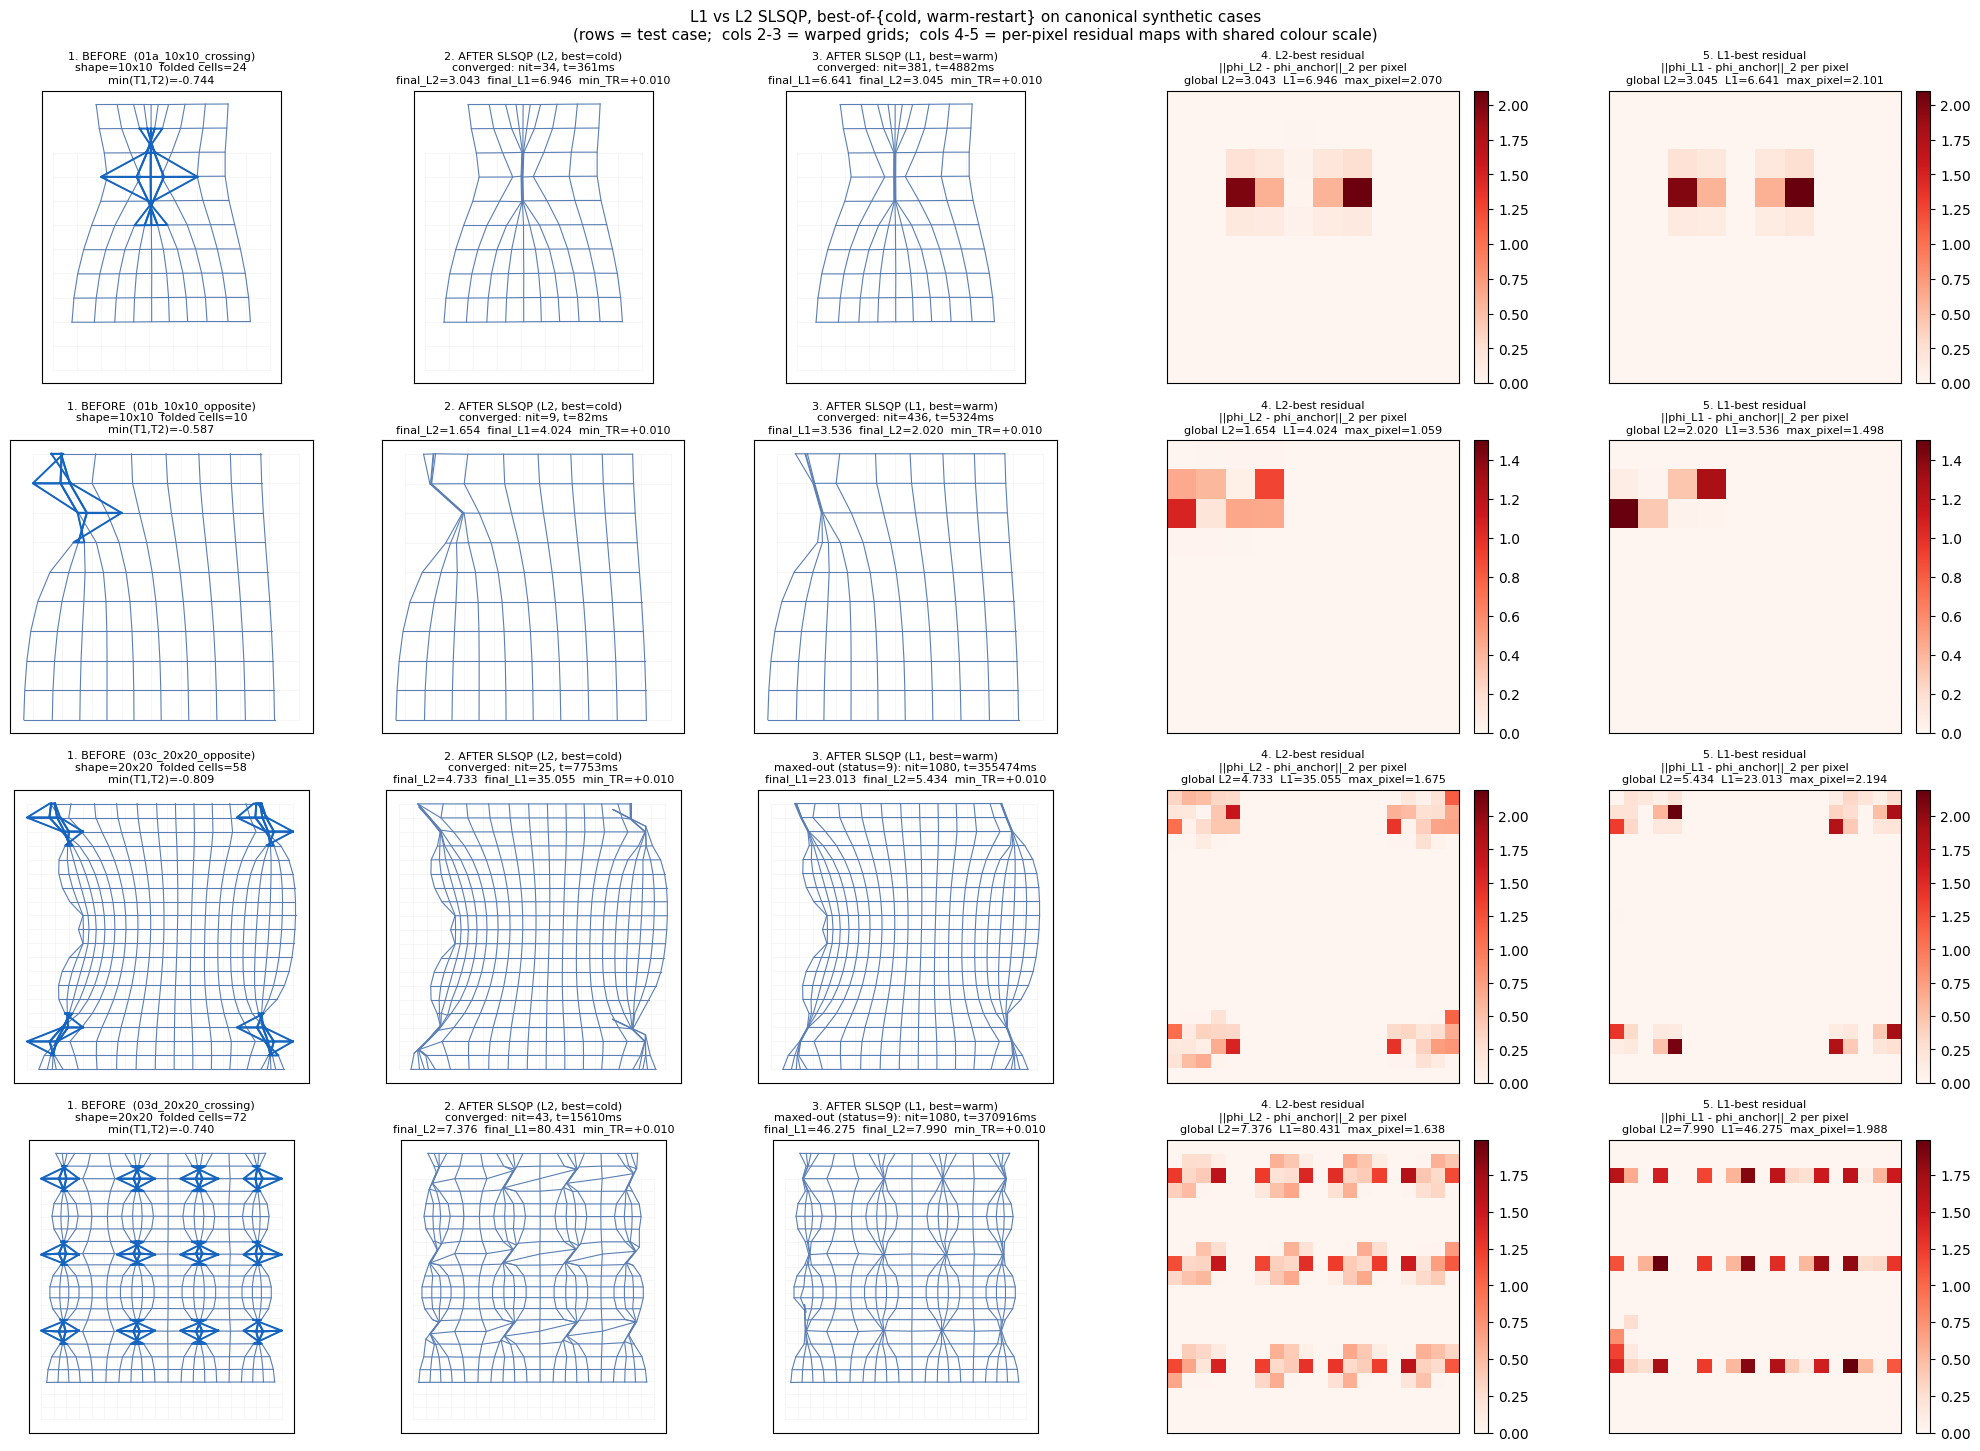

In [6]:
fig, axes = plt.subplots(len(CASES), 5, figsize=(20.0, 3.6 * len(CASES)),
                          layout='constrained', squeeze=False)
for row_i, (name, phi, _it_l2, _it_l1) in enumerate(CASES):
    rr = results[name]
    rl2 = _best_run(rr, 'l2')
    rl1 = _best_run(rr, 'l1')
    mode_l2 = 'cold' if rl2 is rr[('l2', 'cold')] else 'warm'
    mode_l1 = 'cold' if rl1 is rr[('l1', 'cold')] else 'warm'

    res_l2_map = per_pixel_residual_l2(rl2['phi'], phi)
    res_l1_map = per_pixel_residual_l2(rl1['phi'], phi)
    vmax = max(res_l2_map.max(), res_l1_map.max(), 1e-6)

    n_orig = int((triangle_sign_areas2D(phi) <= 0).sum())
    orig_min_tr = float(triangle_sign_areas2D(phi).min())

    plot_warped_grid(axes[row_i, 0], phi,
        f'1. BEFORE  ({name})\n'
        f'shape={phi.shape[1]}x{phi.shape[2]}  folded cells={n_orig}\n'
        f'min(T1,T2)={orig_min_tr:+.3f}')

    status_l2 = 'converged' if rl2['success'] else f'maxed-out (status={rl2["status"]})'
    plot_warped_grid(axes[row_i, 1], rl2['phi'],
        f'2. AFTER SLSQP (L2, best={mode_l2})\n'
        f'{status_l2}: nit={rl2["nit"]}, t={1000*rl2["t"]:.0f}ms\n'
        f'final_L2={rl2["final_l2"]:.3f}  final_L1={rl2["final_l1"]:.3f}  '
        f'min_TR={rl2["min_tr"]:+.3f}')

    status_l1 = 'converged' if rl1['success'] else f'maxed-out (status={rl1["status"]})'
    plot_warped_grid(axes[row_i, 2], rl1['phi'],
        f'3. AFTER SLSQP (L1, best={mode_l1})\n'
        f'{status_l1}: nit={rl1["nit"]}, t={1000*rl1["t"]:.0f}ms\n'
        f'final_L1={rl1["final_l1"]:.3f}  final_L2={rl1["final_l2"]:.3f}  '
        f'min_TR={rl1["min_tr"]:+.3f}')

    im4 = axes[row_i, 3].imshow(res_l2_map, cmap='Reds', vmin=0, vmax=vmax)
    axes[row_i, 3].set_title(
        f'4. L2-best residual\n'
        f'||phi_L2 - phi_anchor||_2 per pixel\n'
        f'global L2={rl2["final_l2"]:.3f}  L1={rl2["final_l1"]:.3f}  '
        f'max_pixel={res_l2_map.max():.3f}', fontsize=8)
    axes[row_i, 3].set_xticks([]); axes[row_i, 3].set_yticks([])
    fig.colorbar(im4, ax=axes[row_i, 3], fraction=0.046, pad=0.04)

    im5 = axes[row_i, 4].imshow(res_l1_map, cmap='Reds', vmin=0, vmax=vmax)
    axes[row_i, 4].set_title(
        f'5. L1-best residual\n'
        f'||phi_L1 - phi_anchor||_2 per pixel\n'
        f'global L2={rl1["final_l2"]:.3f}  L1={rl1["final_l1"]:.3f}  '
        f'max_pixel={res_l1_map.max():.3f}', fontsize=8)
    axes[row_i, 4].set_xticks([]); axes[row_i, 4].set_yticks([])
    fig.colorbar(im5, ax=axes[row_i, 4], fraction=0.046, pad=0.04)

plt.suptitle(
    'L1 vs L2 SLSQP, best-of-{cold, warm-restart} on canonical synthetic cases\n'
    '(rows = test case;  cols 2-3 = warped grids;  cols 4-5 = per-pixel residual maps with shared colour scale)',
    fontsize=11)
plt.show()

## Observations

Concrete results from this run (THRESHOLD = 0.01, smoothed-L1 ε = 1e-4):

| case | obj | mode | ok | nit | t (ms) | final L2 | final L1 | min_TR | warm fired? |
|---|---|---|---|---:|---:|---:|---:|---:|---|
| 01a_10x10_crossing | L2 | cold | ✓ | 34 | 361 | 3.043 | 6.946 | +0.010 | – |
| 01a_10x10_crossing | L2 | warm | ✓ | 34 | 367 | 3.043 | 6.946 | +0.010 | no |
| 01a_10x10_crossing | **L1** | cold | ✗ | 50 | 699 | 3.927 | 16.873 | +0.004 | – |
| 01a_10x10_crossing | **L1** | **warm** | **✓** | **381** | **4 882** | 3.045 | **6.641** | **+0.010** | **yes (status=9)** |
| 01b_10x10_opposite | L2 | cold | ✓ | 9 | 82 | 1.654 | 4.024 | +0.010 | – |
| 01b_10x10_opposite | **L1** | cold | ✗ | 50 | 577 | 3.571 | 13.193 | +0.005 | – |
| 01b_10x10_opposite | **L1** | **warm** | **✓** | **436** | **5 324** | 2.020 | **3.536** | **+0.010** | **yes (status=9)** |
| 03c_20x20_opposite | L2 | cold | ✓ | 25 | 7 753 | 4.733 | 35.055 | +0.010 | – |
| 03c_20x20_opposite | **L1** | cold | ✗ | 80 | 36 859 | 10.397 | 59.195 | **−0.008** | – |
| 03c_20x20_opposite | **L1** | **warm** | ✗ (cap) | **1 080** | **355 474** | 5.434 | **23.013** | **+0.010** | **yes (status=9)** |
| 03d_20x20_crossing | L2 | cold | ✓ | 43 | 15 610 | 7.376 | 80.431 | +0.010 | – |
| 03d_20x20_crossing | **L1** | cold | ✗ | 80 | 41 678 | 11.576 | 113.888 | **−0.004** | – |
| 03d_20x20_crossing | **L1** | **warm** | ✗ (cap) | **1 080** | **370 916** | 7.990 | **46.275** | **+0.010** | **yes (status=9)** |

### What the warm-restart did

- **Trigger.** Every cold L1 run terminated with `status=9` (max-iter reached) — *not* the `status=8` (line-search rejection) the original notebook-02 recipe was tuned for. The generalised trigger we added (`not res.success`) caught these and resumed with the extra budget. Without that generalisation, the warm-restart never fired and L1 stayed broken.
- **No perturbation needed.** Because the failure was iter-exhaustion rather than line-search degeneracy, the resume was a plain "give it more iterations" — no Gaussian noise. (The σ=0.01 perturb branch is still there for `status=8` cases and is what rescues bowtie-L1 in `10_preprocessing-warm-start.ipynb`.)
- **L2 was unaffected.** All L2 runs converged from cold within the small budget, so their warm runs are no-ops. L2 SLSQP is just much easier than L1 on these constraints.

### Quality after rescue

- **10×10 cases** (`01a`, `01b`): L1-warm fully converged (`success=True`, feasible). The expected L1-vs-L2 contrast holds: L1-warm has lower `final_L1` (6.64 vs L2's 6.95 on `01a`; 3.54 vs 4.02 on `01b`) and slightly higher `final_L2` (3.045 vs 3.043 on `01a`; 2.02 vs 1.65 on `01b`). L1 is buying its own metric, paying a small price in the other.
- **20×20 cases** (`03c`, `03d`): L1-warm reached feasibility (`min_TR = +0.010`) but hit the 1080-iter cap before formally converging. Even so, `final_L1` dropped from 59 → 23 on `03c` and 114 → 46 on `03d` — a 2.5–2.6× improvement over the cold result. L1's `final_L1` is now well below L2's (23 vs 35 on `03c`, 46 vs 80 on `03d`), confirming that L1 is the better choice for that metric once it has enough iterations to converge.

### Sparsity vs spread (cols 4–5 of the figure)

The two residual heatmaps share a colour scale, so reading them side-by-side: L2's residual is smoothly distributed across many pixels (squared cost rewards distribution); L1's residual is concentrated on a smaller pixel set with larger per-pixel magnitudes (sparsity is rewarded). On all four cases the contrast is now visible — for the 20×20 cases this would only sharpen further with more iterations.

### Bottom line

- **The reactive warm-restart from `02_optimization.ipynb` does work for L1, with one caveat:** the original trigger (`status=8`) is too narrow. Generalising to `not res.success` and resuming without perturbation when `status=9` (iter limit) is what actually rescues L1 on these cases. The σ=0.01 perturb branch is still relevant for `status=8` stalls.
- **L1 is genuinely 10–25× more iteration-hungry than L2** from a cold start on these constraints. Plan for it.
- **For 10×10 cases the warm-restart fully rescues L1** (`success=True`, feasible) at ~5s wall-clock — practical. For 20×20 the warm-restart reaches feasibility but doesn't formally converge inside the 1080-iter cap; it would need ~3000+ iterations or a *proactive* warm-start (the preprocessing strategies in `10_preprocessing-warm-start.ipynb`, especially `S1 alpha-bisection`) to converge cleanly. Combining the two — preprocessing for the *start*, reactive warm-restart for *stalls* — is the obvious next experiment.